This notebook trains adversarial policies using Generative Adversarial Imitation Learning (GAIL) with Evolutionary Strategies to match expert behavior distributions across 16-prey and 32-prey conditions using separate discriminators for predator and prey. Expert trajectories are generated synthetically from a Couzin swarm model to provide a controlled baseline.

## GAIL - Couzin Predator-Prey

In [ ]:
# install and then restart session after so that the new versions can be picked up
from google.colab import drive
drive.mount('/content/drive') # need to be mounted so that requirements is accessible

!pip install ema-pytorch geomloss[full] pykeops ultralytics deep-sort-realtime -q
!pip install -r /content/drive/MyDrive/Master-Thesis/requirements.txt -q
!pip install "numpy==2.0.2" --force-reinstall -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 35.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 132.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.4/319.4 kB 34.3 MB/s eta 0:00:00
ERROR: Could not open requirements file: [Errno 2] No such file or directory: '/content/drive/MyDrive/Master-Thesis/requirements.txt'
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 103.8 MB/s eta 0:00:00
  Installing build dependencies ... done
 

### Training


In [ ]:
# set working directory
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content/drive/MyDrive/Predator Prey Thesis')
sys.path.insert(0, '/content/drive/MyDrive/Predator Prey Thesis')

import numpy as np
print(np.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2.0.2


In [ ]:
# set PyTorch memory allocation for GPU efficiency
import os
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
# imports
import torch
from pathlib import Path
from ema_pytorch import EMA
from datetime import datetime
import random, numpy as np, torch

# project specific helper modules
from utils.sim_utils import *
from utils.eval_utils import *
from utils.train_utils import *
from utils.couzin_utils import *
from utils.vec_sim_utils import *
from utils.encoder_utils import *
from utils.dataset_utils import pad_expert_tensors, pad_rollout_tensors

# sinkhorn
from geomloss import SamplesLoss

# maximum mean discrepency
from utils.mmd_loss import MMDLoss

from models.Generator import ModularPolicy
from models.Discriminator import Discriminator
from models.JointDiscriminator import JointDiscriminator

[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK


In [ ]:
# expert data generation
max_steps = 300         # steps per episode

# Training Setup
num_generations = 3000  # training generations
gamma = 0.999           # decay factor
pretrain = False        # BC pretrain
performance_eval = 5    # evaluate performance every n generations
num_perturbations = 64  # perturbations for ES (how many candidate policy perturbations each ES step evaluates)


### Prey ###
lr_prey_policy = 2e-4   # learning rate prey policy
sigma_prey = 0.1        # prey scatter for ES (exploration strength)

prey_dis_balance_factor = 2 # prey discriminator steps per policy step
prey_noise = 0.005      # prey discriminator input noise
lr_prey_disc = 5e-4     # learning rate prey discriminator
lambda_gp_prey = 5      # prey gradient penalty factor
prey_update_mode = {"mode": "avoid", "lambda": 0.2} # prey update mode


### Predator ###
lr_pred_policy = 1e-4   # learning rate predator policy
sigma_pred = 0.08       # pred scatter for ES (exploration)

pred_dis_balance_factor = 2 # pred discriminator steps per policy step
pred_noise = 0.005      # pred discriminator input noise
lr_pred_disc = 2e-4     # learning rate pred discriminator
lambda_gp_pred = 10     # pred gradient penalty factor
pred_update_mode = {"mode": "attack", "lambda": 0.1} # pred update mode


# env settings
height = 50
width = 50
prey_speed = 5
pred_speed = 5
step_size = 0.25
theta_dot_max = 0.5 # max turn rate
max_turn = float(theta_dot_max * step_size) + 1e-12 # max turn per step

pert_steps = 100 # perturbation steps
init_steps = 500 # initial steps

max_speed_norm = float(max(prey_speed, pred_speed))
env_settings = (height, width, prey_speed, pred_speed, step_size, max_turn, pert_steps, max_speed_norm)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# seeds for reproducibility
import random
import numpy as np
import torch
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# generate two swarms
exp_pred_sequence_32, exp_prey_sequence_32, couzin_metrics_32, actions_32, init_pool_32 = run_couzin_simulation(
    visualization="off", max_steps=init_steps, constant_speed=prey_speed, shark_speed=pred_speed,
    area_width=width, area_height=height, dt=step_size, alpha=0.01, theta_dot_max=theta_dot_max,
    theta_dot_max_shark=theta_dot_max, number_of_sharks=1, n=32)

exp_pred_sequence_16, exp_prey_sequence_16, couzin_metrics_16, actions_16, init_pool_16 = run_couzin_simulation(
    visualization="off", max_steps=init_steps, constant_speed=prey_speed, shark_speed=pred_speed,
    area_width=width, area_height=height, dt=step_size, alpha=0.01, theta_dot_max=theta_dot_max,
    theta_dot_max_shark=theta_dot_max, number_of_sharks=1, n=16)

exp_pred_tensor_32 = sliding_window(exp_pred_sequence_32, window_size=10)
exp_prey_tensor_32 = sliding_window(exp_prey_sequence_32, window_size=10)
exp_pred_tensor_16 = sliding_window(exp_pred_sequence_16, window_size=10)
exp_prey_tensor_16 = sliding_window(exp_prey_sequence_16, window_size=10)

exp_pred_tensor_32, exp_prey_tensor_32 = pad_expert_tensors(exp_pred_tensor_32, exp_prey_tensor_32, max_prey=32)
exp_pred_tensor_16, exp_prey_tensor_16 = pad_expert_tensors(exp_pred_tensor_16, exp_prey_tensor_16, max_prey=32)

# now move the padded results (and init pools) to device
exp_pred_tensor_32 = exp_pred_tensor_32.to(device)
exp_prey_tensor_32 = exp_prey_tensor_32.to(device)
exp_pred_tensor_16 = exp_pred_tensor_16.to(device)
exp_prey_tensor_16 = exp_prey_tensor_16.to(device)
init_pool_32 = init_pool_32.to(device)
init_pool_16 = init_pool_16.to(device)

print("\nPred Tensor Shape (32):", exp_pred_tensor_32.shape)
print("Prey Tensor Shape (32):", exp_prey_tensor_32.shape)
print("\nPred Tensor Shape (16):", exp_pred_tensor_16.shape)
print("Prey Tensor Shape (16):", exp_prey_tensor_16.shape)


Pred Tensor Shape (32): torch.Size([491, 10, 1, 32, 6])
Prey Tensor Shape (32): torch.Size([491, 10, 32, 32, 7])

Pred Tensor Shape (16): torch.Size([491, 10, 1, 32, 6])
Prey Tensor Shape (16): torch.Size([491, 10, 32, 32, 7])


epoch 010: loss=22.995991 sim=0.0485 std=1.3362 cov=0.3479 std_mean=0.332
epoch 020: loss=22.079441 sim=0.0385 std=1.2703 cov=0.4122 std_mean=0.365
epoch 030: loss=21.423441 sim=0.0368 std=1.2276 cov=0.4177 std_mean=0.386
epoch 040: loss=20.745533 sim=0.0349 std=1.1717 cov=0.4595 std_mean=0.414
epoch 050: loss=20.254631 sim=0.0355 std=1.1257 cov=0.4966 std_mean=0.437
epoch 060: loss=19.969210 sim=0.0364 std=1.0942 cov=0.5289 std_mean=0.453
epoch 070: loss=19.779259 sim=0.0359 std=1.0693 cov=0.5683 std_mean=0.465
epoch 080: loss=19.679258 sim=0.0362 std=1.0478 cov=0.6115 std_mean=0.476
epoch 090: loss=19.382175 sim=0.0351 std=1.0405 cov=0.5798 std_mean=0.480
epoch 100: loss=19.291767 sim=0.0366 std=1.0241 cov=0.6027 std_mean=0.488
epoch 110: loss=19.149420 sim=0.0376 std=1.0009 cov=0.6394 std_mean=0.500
epoch 120: loss=19.065258 sim=0.0361 std=1.0010 cov=0.6295 std_mean=0.500
epoch 130: loss=18.986139 sim=0.0372 std=0.9846 cov=0.6575 std_mean=0.508
epoch 140: loss=18.895706 sim=0.0378 s

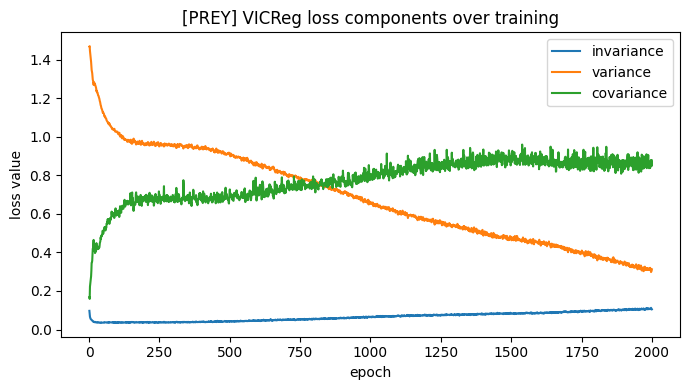

Prey Encoder trained & frozen.

epoch 010: loss=22.938200 sim=0.0470 std=1.3415 cov=0.3281 std_mean=0.329
epoch 020: loss=22.144501 sim=0.0398 std=1.2635 cov=0.4393 std_mean=0.368
epoch 030: loss=21.374578 sim=0.0322 std=1.2304 cov=0.4227 std_mean=0.385
epoch 040: loss=21.069136 sim=0.0327 std=1.1912 cov=0.4770 std_mean=0.404
epoch 050: loss=20.741514 sim=0.0327 std=1.1758 cov=0.4572 std_mean=0.412
epoch 060: loss=20.523460 sim=0.0330 std=1.1416 cov=0.5148 std_mean=0.429
epoch 070: loss=20.243492 sim=0.0325 std=1.1290 cov=0.4994 std_mean=0.435
epoch 080: loss=20.307810 sim=0.0351 std=1.1110 cov=0.5531 std_mean=0.444
epoch 090: loss=20.079491 sim=0.0352 std=1.1049 cov=0.5252 std_mean=0.448
epoch 100: loss=19.949453 sim=0.0319 std=1.0811 cov=0.5872 std_mean=0.459
epoch 110: loss=19.767809 sim=0.0323 std=1.0696 cov=0.5832 std_mean=0.465
epoch 120: loss=19.663565 sim=0.0326 std=1.0549 cov=0.6048 std_mean=0.473
epoch 130: loss=19.836329 sim=0.0377 std=1.0569 cov=0.6080 std_mean=0.472
epoch 

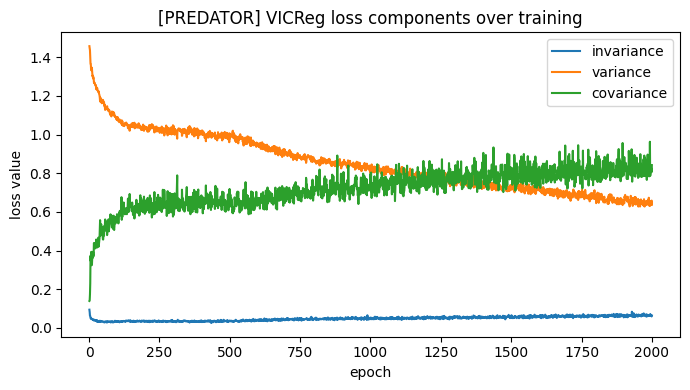

Predator Encoder trained & frozen.


In [ ]:
# initialize trajectory augmentation
# this creates two augmented views of the same trajectory segment for self-supervised training (labels created from data itself)
aug = TrajectoryAugmentation(noise_std=0.01, neigh_drop=0.10, feat_drop=0.05).to(device)

# combine 16 and 32 prey
exp_prey_tensor_all = torch.cat([exp_prey_tensor_32, exp_prey_tensor_16], dim=0)
exp_pred_tensor_all = torch.cat([exp_pred_tensor_32, exp_pred_tensor_16], dim=0)

# prey encoder training
prey_encoder = TransitionEncoder(features=6, embd_dim=32, z=32).to(device)   # was 5
prey_projector = VicRegProjector(input_dim=64).to(device)
prey_optimizer = torch.optim.Adam(list(prey_encoder.parameters()) + list(prey_projector.parameters()), lr=1e-3, weight_decay=1e-6)
train_encoder(prey_encoder, prey_projector, aug=aug, exp_tensor=exp_prey_tensor_all, epochs=2000, optimizer=prey_optimizer, role="prey")

# freeze prey encoder
for p in prey_encoder.parameters():
    p.requires_grad = False
prey_encoder.eval()
print("Prey Encoder trained & frozen.\n")

# predator encoder training
pred_encoder = TransitionEncoder(features=5, embd_dim=32, z=32).to(device)   # was 4
pred_projector = VicRegProjector(input_dim=64).to(device)
pred_optimizer = torch.optim.Adam(list(pred_encoder.parameters()) + list(pred_projector.parameters()), lr=1e-3, weight_decay=1e-6)
train_encoder(pred_encoder, pred_projector, aug=aug, exp_tensor=exp_pred_tensor_all, epochs=2000, optimizer=pred_optimizer, role="predator")
# freeze predator encoder
for p in pred_encoder.parameters():
    p.requires_grad = False
pred_encoder.eval()
print("Predator Encoder trained & frozen.")

In [ ]:
# initialize prey policy
prey_policy  = ModularPolicy(features=6).to(device) # was 5
prey_policy.set_parameters()

# pretrain prey policy with behavior cloning
if pretrain:
    pretrain_policy(prey_policy, expert_data=exp_prey_tensor_all, role="prey", batch_size=4048, epochs=5, lr=1e-3, deterministic=True, device=device)

# initialize EMA for prey policy
ema_prey = EMA(prey_policy, beta=0.9999, update_after_step=10, update_every=5, allow_different_devices=True)
print("Prey Policy initialized.\n")

Prey Policy initialized.



In [ ]:
# initialize predator policy
pred_policy  = ModularPolicy(features=5).to(device) # was 4
pred_policy.set_parameters()

# pretrain predator policy with behavior cloning
if pretrain:
    pretrain_policy(pred_policy, expert_data=exp_pred_tensor_all, role="predator", batch_size=4048, epochs=5, lr=1e-3, deterministic=True, device=device)

# initialize EMA for predator policy
ema_pred = EMA(pred_policy, beta=0.9999, update_after_step=10, update_every=5, allow_different_devices=True)
print("Predator Policy initialized.\n")

Predator Policy initialized.



In [ ]:
# initialize prey discriminator
prey_discriminator = Discriminator(encoder=prey_encoder, role="prey", z_dim=32).to(device)
prey_discriminator.set_parameters(init=True)
optim_disc_prey = torch.optim.RMSprop(prey_discriminator.parameters(), lr=lr_prey_disc, alpha=0.99, eps=1e-08)

# initialize predator discriminator
pred_discriminator = Discriminator(encoder=pred_encoder, role="predator", z_dim=32).to(device)
pred_discriminator.set_parameters(init=True)
optim_disc_pred = torch.optim.RMSprop(pred_discriminator.parameters(), lr=lr_pred_disc, alpha=0.99, eps=1e-08)

# initialize losses
prey_mmd_loss = MMDLoss(encoder=prey_encoder, role="prey").to(device)
pred_mmd_loss = MMDLoss(encoder=pred_encoder, role="predator").to(device)
sinkhorn_loss = SamplesLoss(loss="sinkhorn", backend="tensorized")

In [ ]:
mmd_means, mmd_stds, sinkhorn_means, sinkhorn_stds = get_expert_values(
    exp_pred_tensor=exp_pred_tensor_32, exp_prey_tensor=exp_prey_tensor_32,
    prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss,
    prey_encoder=prey_encoder, pred_encoder=pred_encoder, sinkhorn_loss=sinkhorn_loss)

  0%|          | 0/500 [00:00<?, ?it/s]


Expert Prey MMD: 0.05554834890365601 ± 0.05248766755327212
Expert Prey Sinkhorn: 0.0001273789986153133 ± 4.020605149557438e-05

Expert Pred MMD: 0.4503937602043152 ± 0.2528007954819854
Expert Pred Sinkhorn: 0.0012116721696802414 ± 0.0003013947345471209


In [ ]:
mmd_means16, mmd_stds16, sinkhorn_means16, sinkhorn_stds16 = get_expert_values(
    exp_pred_tensor=exp_pred_tensor_16, exp_prey_tensor=exp_prey_tensor_16,
    prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss,
    prey_encoder=prey_encoder, pred_encoder=pred_encoder, sinkhorn_loss=sinkhorn_loss)

  0%|          | 0/500 [00:00<?, ?it/s]


Expert Prey MMD: 0.013798332691192627 ± 0.012330839917688305
Expert Prey Sinkhorn: 9.34213985601673e-06 ± 2.4715249151548247e-06

Expert Pred MMD: 0.41408916997909545 ± 0.18032640146494475
Expert Pred Sinkhorn: 0.000311698568664724 ± 7.854533657588045e-05


In [ ]:
run_dir = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16_curriculum')
run_dir.mkdir(parents=True, exist_ok=True)

def sample_n_prey(gen, num_generations, start_p16=0.2, end_p16=0.5, ramp_frac=0.3):
    frac = gen / num_generations
    p16 = start_p16 + (end_p16 - start_p16) * min(frac / ramp_frac, 1.0)
    return 16 if random.random() < p16 else 32

metrics_list = []
metrics_list_16 = []
policy_metrics_list = []
disc_metrics_list = []
gamma = 0.999

best_prey = float("inf")
best_pred = float("inf")
best_prey_policy_state = {k: v.detach().clone() for k, v in ema_prey.ema_model.state_dict().items()}
best_pred_policy_state = {k: v.detach().clone() for k, v in ema_pred.ema_model.state_dict().items()}

# training loop
for gen in range(num_generations):

    # added curriculum sampling
    n_prey = sample_n_prey(gen, num_generations)
    if n_prey == 16:
        cond_init_pool = init_pool_16
        cond_exp_pred_tensor = exp_pred_tensor_16
        cond_exp_prey_tensor = exp_prey_tensor_16
    else:
        cond_init_pool = init_pool_32
        cond_exp_pred_tensor = exp_pred_tensor_32
        cond_exp_prey_tensor = exp_prey_tensor_32

    # use EMA models for rollouts
    rollout_prey_policy = ema_prey.ema_model.to(device)
    rollout_pred_policy = ema_pred.ema_model.to(device)

    # generate rollouts with current EMA policy
    gen_pred_tensor, gen_prey_tensor = run_env_vectorized(prey_policy=rollout_prey_policy,
                                                          pred_policy=rollout_pred_policy,
                                                          n_prey=n_prey, n_pred=1, max_steps=100,
                                                          init_pool=cond_init_pool)
    gen_pred_tensor, gen_prey_tensor = pad_rollout_tensors(gen_pred_tensor, gen_prey_tensor, max_prey=32)

    for i in range(pred_dis_balance_factor):
        # sample batches for discriminator update
        expert_pred_batch, _ = sample_data(cond_exp_pred_tensor, batch_size=20, window_len=10)
        generative_pred_batch, _ = sample_data(gen_pred_tensor, batch_size=20, window_len=10)
        expert_pred_batch = expert_pred_batch.to(device)
        generative_pred_batch = generative_pred_batch.to(device)
        # predator discriminator update
        dis_metric_pred = pred_discriminator.update(expert_pred_batch, generative_pred_batch, optim_disc_pred,
                                                    lambda_gp_pred, noise=pred_noise, generation=gen, num_generations=num_generations)
    for i in range(prey_dis_balance_factor):
        # sample batches for discriminator update
        expert_prey_batch, _ = sample_data(cond_exp_prey_tensor, batch_size=10, window_len=10)
        generative_prey_batch, _ = sample_data(gen_prey_tensor, batch_size=10, window_len=10)
        expert_prey_batch = expert_prey_batch.to(device)
        generative_prey_batch = generative_prey_batch.to(device)
        # prey discriminator update
        dis_metric_prey = prey_discriminator.update(expert_prey_batch, generative_prey_batch, optim_disc_prey,
                                                    lambda_gp_prey, noise=prey_noise, generation=gen, num_generations=num_generations)
        disc_metrics_list.append((dis_metric_prey, dis_metric_pred))

    # sample initial positions for ES, same positions for all perturbations
    init_pos = init_positions(cond_init_pool, batch=num_perturbations, mode="dual")

    # optimize pred PIN with ES
    pin_pred_metrics = optimize_es(pred_policy=pred_policy, prey_policy=prey_policy, n_prey=n_prey,
                                   role="pred", module="pairwise", mode=pred_update_mode,
                                   discriminator=pred_discriminator, lr=lr_pred_policy, sigma=sigma_pred,
                                   num_perturbations=num_perturbations, init_pos=init_pos,
                                   settings_batch_env=env_settings)

    # optimize pred AN with ES
    an_pred_metrics  = optimize_es(pred_policy=pred_policy, prey_policy=prey_policy, n_prey=n_prey,
                                   role="pred", module="attention", mode=pred_update_mode,
                                   discriminator=pred_discriminator, lr=lr_pred_policy, sigma=sigma_pred,
                                   num_perturbations=num_perturbations, init_pos=init_pos,
                                   settings_batch_env=env_settings)
    ema_pred.update() # update EMA predator policy

    # optimize prey PIN with ES
    pin_prey_metrics = optimize_es(pred_policy=pred_policy, prey_policy=prey_policy, n_prey=n_prey,
                                   role="prey", module="pairwise", mode=prey_update_mode,
                                   discriminator=prey_discriminator, lr=lr_prey_policy, sigma=sigma_prey,
                                   num_perturbations=num_perturbations, init_pos=init_pos,
                                   settings_batch_env=env_settings)

    # optimize prey AN with ES
    an_prey_metrics  = optimize_es(pred_policy=pred_policy, prey_policy=prey_policy, n_prey=n_prey,
                                   role="prey", module="attention", mode=prey_update_mode,
                                   discriminator=prey_discriminator, lr=lr_prey_policy, sigma=sigma_prey,
                                   num_perturbations=num_perturbations, init_pos=init_pos,
                                   settings_batch_env=env_settings)
    ema_prey.update() # update EMA prey policy

    # append metrics
    policy_metrics_list.append({"predator": (pin_pred_metrics, an_pred_metrics), "prey": (pin_prey_metrics, an_prey_metrics)})

    # decay learning rate and sigma
    lr_pred_policy *= gamma
    lr_prey_policy *= gamma
    sigma_pred *= gamma
    sigma_prey *= gamma

    # evalute current policies
    if gen % performance_eval == 0:

        # calculate Sinkhorn and MMD metrics
        m32 = calculate_metrics(pred_policy=pred_policy, prey_policy=prey_policy,
                              prey_encoder=prey_encoder, pred_encoder=pred_encoder,
                              exp_prey_tensor=exp_prey_tensor_32, exp_pred_tensor=exp_pred_tensor_32,
                              prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss, sinkhorn_loss=sinkhorn_loss,
                              init_pool=init_pool_32, n_prey=32, env_settings=env_settings, device="cuda")
        m16 = calculate_metrics(pred_policy=pred_policy, prey_policy=prey_policy,
                              prey_encoder=prey_encoder, pred_encoder=pred_encoder,
                              exp_prey_tensor=exp_prey_tensor_16, exp_pred_tensor=exp_pred_tensor_16,
                              prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss, sinkhorn_loss=sinkhorn_loss,
                              init_pool=init_pool_16, n_prey=16, env_settings=env_settings, device="cuda")
        metrics = m32
        metrics_list.append(m32)
        metrics_list_16.append({"gen": gen, **m16})

        current_prey_state = ema_prey.ema_model.state_dict()
        current_pred_state = ema_pred.ema_model.state_dict()

        if metrics["sinkhorn_prey_mean"] < best_prey:
            best_prey = metrics["sinkhorn_prey_mean"]
            best_prey_policy_state = {k: v.detach().clone() for k, v in current_prey_state.items()}
            print(f"New best Prey Sinkhorn: {best_prey.item()}\n")

        if metrics["sinkhorn_pred_mean"] < best_pred:
            best_pred = metrics["sinkhorn_pred_mean"]
            best_pred_policy_state = {k: v.detach().clone() for k, v in current_pred_state.items()}
            print(f"New best Predator Sinkhorn: {best_pred.item()}\n")

    print("Generation", gen+1, f"[n_prey={n_prey}]")
    print(f"[PREY] PIN Network:   {pin_prey_metrics}")
    print(f"[PREY] AN Network:    {an_prey_metrics}")
    print(f"[PREY] Discriminator: {dis_metric_prey}")
    print(f"[PREY] Score Diff: {abs(dis_metric_prey['expert_score_mean'] - dis_metric_prey['policy_score_mean'])}")
    print(f"[PREY] MMD: {metrics['mmd_prey_mean']:.4f} ± {metrics['mmd_prey_std']:.4f} | Sinkhorn: {metrics['sinkhorn_prey_mean']:.4f} ± {metrics['sinkhorn_prey_std']:.4f}")
    print("--------------------------------")
    print(f"[PRED] PIN Network:   {pin_pred_metrics}")
    print(f"[PRED] AN Network:    {an_pred_metrics}")
    print(f"[PRED] Discriminator: {dis_metric_pred}")
    print(f"[PRED] Score Diff: {abs(dis_metric_pred['expert_score_mean'] - dis_metric_pred['policy_score_mean'])}")
    print(f"[PRED] MMD: {metrics['mmd_pred_mean']:.4f} ± {metrics['mmd_pred_std']:.4f} | Sinkhorn: {metrics['sinkhorn_pred_mean']:.4f} ± {metrics['sinkhorn_pred_std']:.4f}\n")

    # periodic checkpoint
    if (gen + 1) % 50 == 0:
        torch.save({
            "gen": gen,
            "prey_policy": prey_policy.state_dict(), "pred_policy": pred_policy.state_dict(),
            "ema_prey": ema_prey.state_dict(), "ema_pred": ema_pred.state_dict(),
            "prey_disc": prey_discriminator.state_dict(), "pred_disc": pred_discriminator.state_dict(),
            "optim_disc_prey": optim_disc_prey.state_dict(), "optim_disc_pred": optim_disc_pred.state_dict(),
            "best_prey_policy_state": best_prey_policy_state, "best_pred_policy_state": best_pred_policy_state,
            "best_prey": best_prey, "best_pred": best_pred,
            "lr_pred_policy": lr_pred_policy, "lr_prey_policy": lr_prey_policy,
            "sigma_pred": sigma_pred, "sigma_prey": sigma_prey,
            "metrics_list": metrics_list, "metrics_list_16": metrics_list_16,
            "policy_metrics_list": policy_metrics_list, "disc_metrics_list": disc_metrics_list,
        }, run_dir / "ckpt_latest.pt")

# load best policies
prey_policy.load_state_dict(best_prey_policy_state, strict=True)
pred_policy.load_state_dict(best_pred_policy_state, strict=True)

# save full metrics history regardless of checkpoint cadence
torch.save({
    "metrics_list": metrics_list,
    "metrics_list_16": metrics_list_16,
    "policy_metrics_list": policy_metrics_list,
    "disc_metrics_list": disc_metrics_list,
}, run_dir / "stage1_metrics.pt")

Streaming output truncated to the last 5000 lines.
[PRED] PIN Network:   {'diff_mean': -0.003112, 'diff_std': 0.046675, 'delta_norm': 0.106904, 'clip_ratio': 0.077068, 'delta_raw_norm': 1.387142, 'max_delta_norm': 0.106904, 'avoid/attack reward': -0.115836}
[PRED] AN Network:    {'diff_mean': 0.013238, 'diff_std': 0.037335, 'delta_norm': 0.105301, 'clip_ratio': 0.075542, 'delta_raw_norm': 1.393946, 'max_delta_norm': 0.105301, 'avoid/attack reward': -0.120326}
[PRED] Discriminator: {'dis_loss': -0.5323, 'dis_loss_gp': -0.4981, 'grad_penalty': 0.0034, 'expert_score_mean': 5.6663, 'policy_score_mean': 5.134}
[PRED] Score Diff: 0.5322999999999993
[PRED] MMD: 1.7159 ± 0.8199 | Sinkhorn: 0.0016 ± 0.0005

Generation 2617 [n_prey=32]
[PREY] PIN Network:   {'diff_mean': 0.00076, 'diff_std': 0.004285, 'delta_norm': 0.106069, 'clip_ratio': 0.058984, 'delta_raw_norm': 1.798254, 'max_delta_norm': 0.106069, 'avoid/attack reward': 0.762148}
[PREY] AN Network:    {'diff_mean': 0.000748, 'diff_std': 0.

In [ ]:
# path for the seeded Stage 1 run
run_dir = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16_curriculum')
run_dir.mkdir(parents=True, exist_ok=True)

torch.save(best_prey_policy_state, run_dir / "prey_policy_stage1.pth")
torch.save(best_pred_policy_state, run_dir / "pred_policy_stage1.pth")

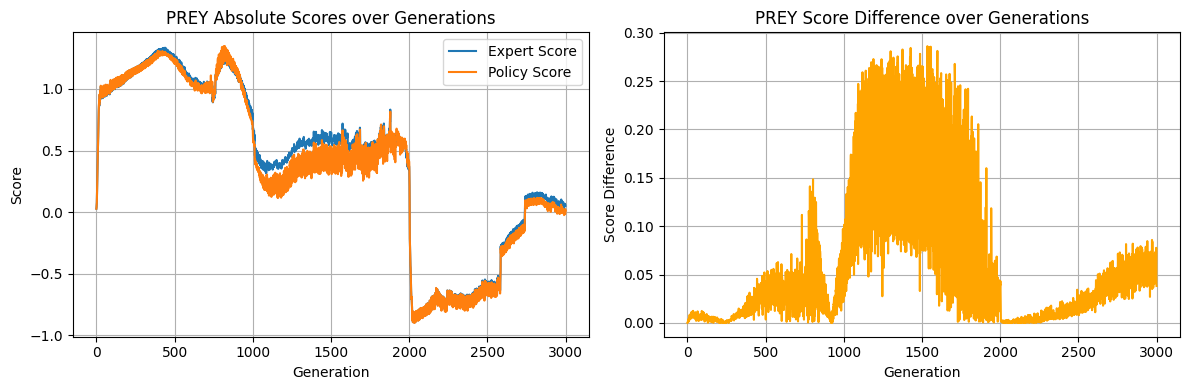

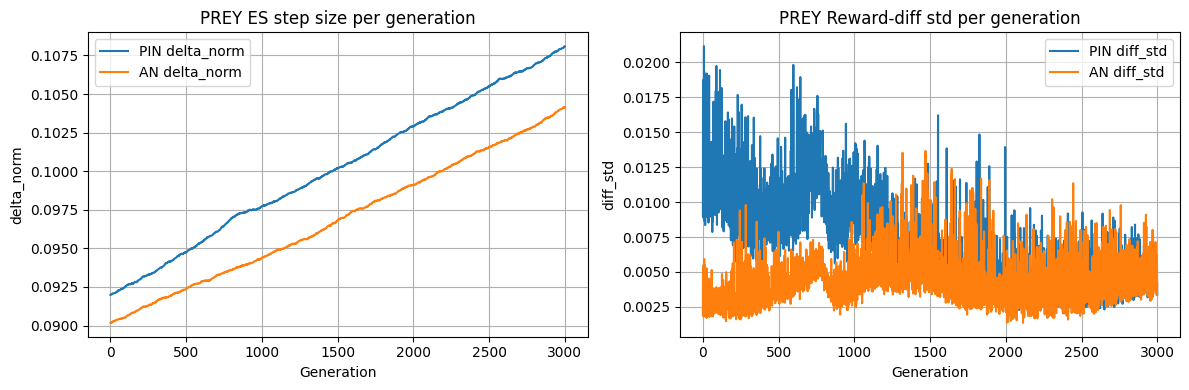

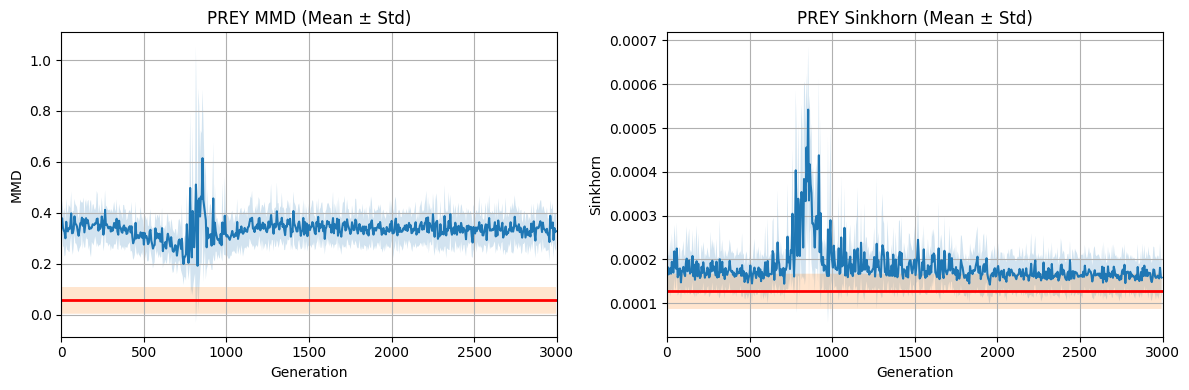

In [ ]:
%matplotlib inline
# plot training and evaluation metrics for prey
plot_train_metrics(disc_metrics_list, prey_dis_balance_factor, role="prey", save_dir=run_dir)
plot_es_metrics(policy_metrics_list, role="prey", save_dir=run_dir)
plot_eval_metrics(metrics_list, role="prey",
                  mmd_means=mmd_means, mmd_stds=mmd_stds,
                  sinkhorn_means=sinkhorn_means, sinkhorn_stds=sinkhorn_stds,
                  max_steps=num_generations, save_dir=run_dir)

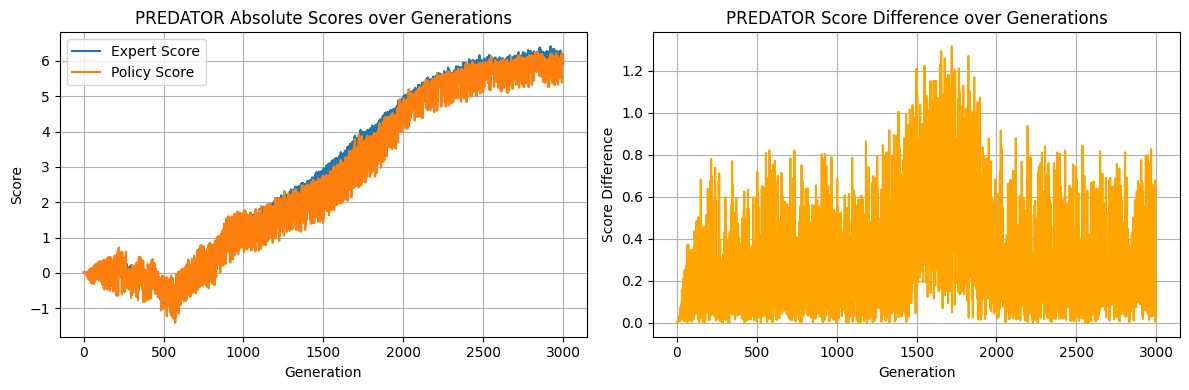

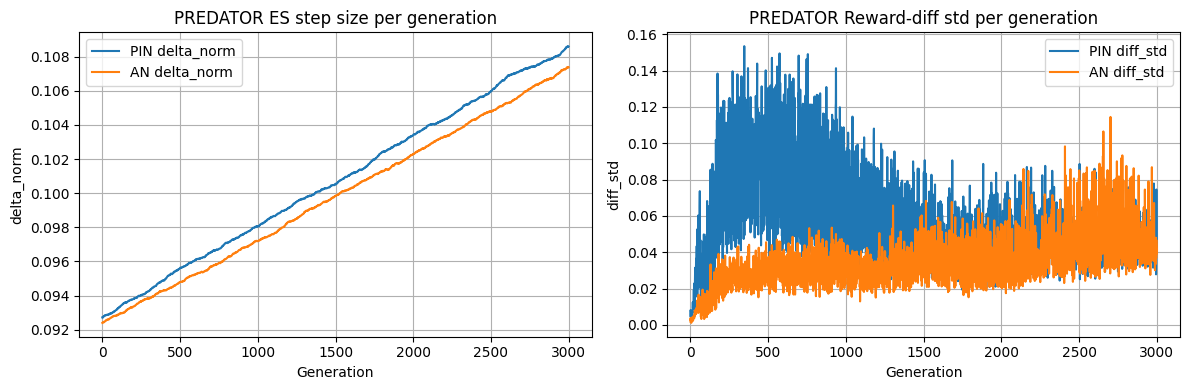

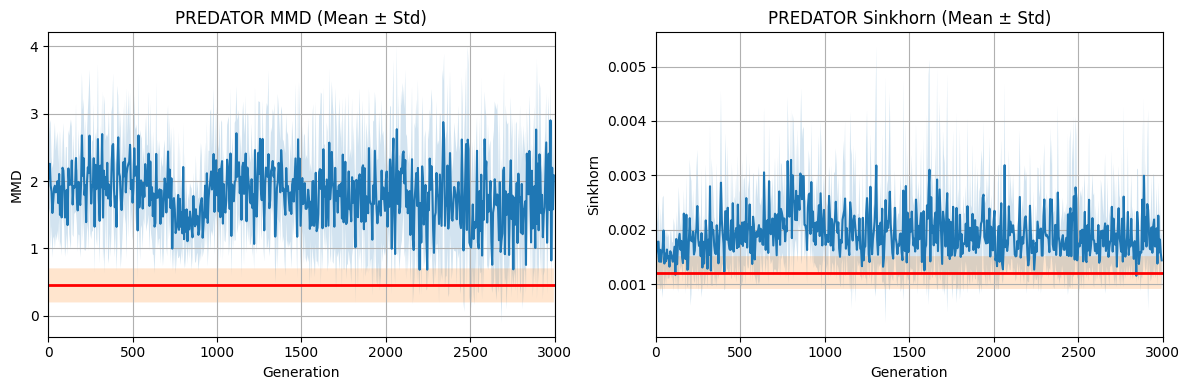

In [ ]:
%matplotlib inline
# plot training and evaluation metrics for predator
plot_train_metrics(disc_metrics_list, pred_dis_balance_factor, role="predator", save_dir=run_dir)
plot_es_metrics(policy_metrics_list, role="predator", save_dir=run_dir)
plot_eval_metrics(metrics_list, role="predator",
                  mmd_means=mmd_means, mmd_stds=mmd_stds,
                  sinkhorn_means=sinkhorn_means, sinkhorn_stds=sinkhorn_stds,
                  max_steps=num_generations, save_dir=run_dir)

[32-prey] final eval: {'mmd_prey_mean': np.float64(0.3632914984226227), 'mmd_prey_std': np.float64(0.08630327182721699), 'mmd_pred_mean': np.float64(1.3402516555786133), 'mmd_pred_std': np.float64(0.8417795644431341), 'sinkhorn_prey_mean': np.float64(0.00015994446213881018), 'sinkhorn_prey_std': np.float64(4.2042112353252185e-05), 'sinkhorn_pred_mean': np.float64(0.0015408048185054212), 'sinkhorn_pred_std': np.float64(0.00040184700507205686)}
[16-prey] final eval: {'mmd_prey_mean': np.float64(0.1017192029953003), 'mmd_prey_std': np.float64(0.022733884843887622), 'mmd_pred_mean': np.float64(1.9700711846351624), 'mmd_pred_std': np.float64(0.6761429453708606), 'sinkhorn_prey_mean': np.float64(1.2394846021379635e-05), 'sinkhorn_prey_std': np.float64(2.954272285451344e-06), 'sinkhorn_pred_mean': np.float64(0.0005578153903479688), 'sinkhorn_pred_std': np.float64(0.00017888979475610508)}


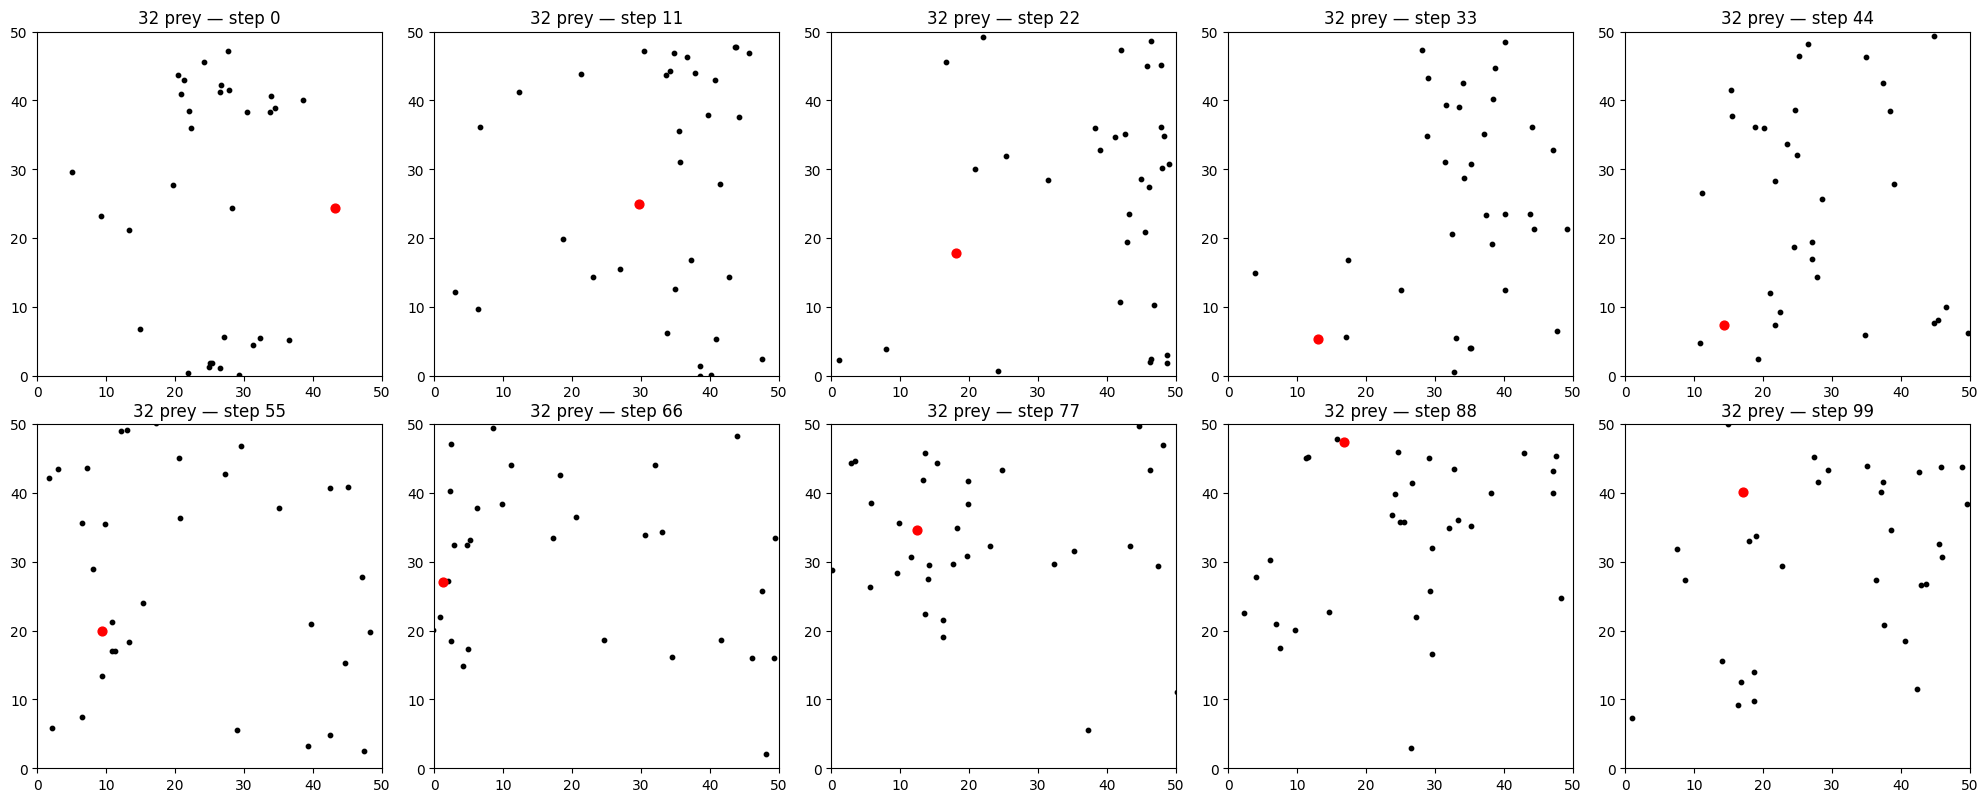

32-prey video: True 586804


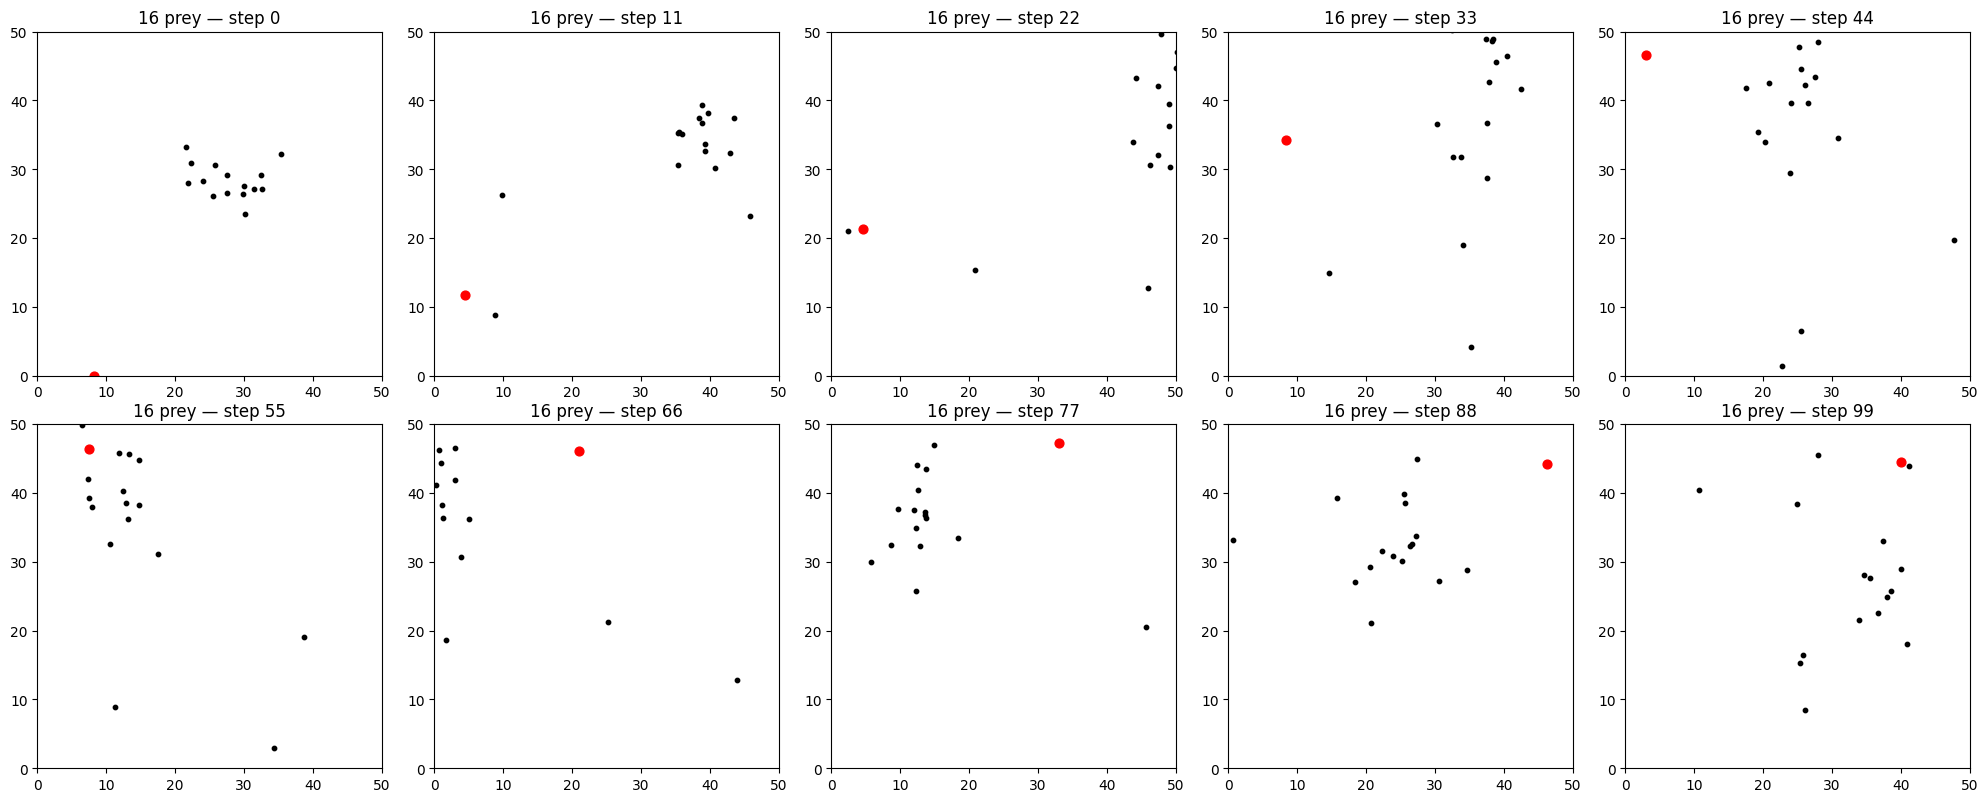

16-prey video: True 332972


In [ ]:
# visualize stage 1 policies

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# final evaluation metrics
for tag, ip, ep, epy, n in [("32", init_pool_32, exp_pred_tensor_32, exp_prey_tensor_32, 32),
                            ("16", init_pool_16, exp_pred_tensor_16, exp_prey_tensor_16, 16)]:
    fm = calculate_metrics(pred_policy=pred_policy, prey_policy=prey_policy,
                           prey_encoder=prey_encoder, pred_encoder=pred_encoder,
                           exp_prey_tensor=epy, exp_pred_tensor=ep,
                           prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss,
                           sinkhorn_loss=sinkhorn_loss, init_pool=ip, n_prey=n,
                           env_settings=env_settings, device="cuda", n_episodes=10)
    print(f"[{tag}-prey] final eval:", fm)

# generate and save rollout visualization
def visualise(n_prey_vis, init_pool_vis, tag):
    _, _, gm = run_env_simulation(visualization='off',
                                  prey_policy=prey_policy, pred_policy=pred_policy,
                                  n_prey=n_prey_vis, n_pred=1, max_steps=100,
                                  pred_speed=pred_speed, prey_speed=prey_speed,
                                  area_width=width, area_height=height,
                                  max_turn=max_turn, step_size=step_size,
                                  max_speed_norm=max_speed_norm, init_pool=init_pool_vis)
    steps, _ = gm

    # static frames
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, s in zip(axes.flat, np.linspace(0, len(steps) - 1, 10, dtype=int)):
        m = steps[s]
        xs, ys = m["xs"] * width, m["ys"] * height
        ax.scatter(xs[1:], ys[1:], c='black', s=10)
        ax.scatter(xs[0],  ys[0],  c='red',   s=40)
        ax.set_xlim(0, width); ax.set_ylim(0, height)
        ax.set_aspect('equal'); ax.set_title(f"{tag} prey — step {s}")
    plt.tight_layout()
    plt.show()

    # animation
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, width); ax.set_ylim(0, height); ax.set_aspect('equal')
    pred_scat = ax.scatter([], [], c='red',  s=60, label='Predator')
    prey_scat = ax.scatter([], [], c='blue', s=20, label='Prey')
    ax.legend(loc='upper right')

    def update(frame):
        m = steps[frame]
        xs = np.asarray(m["xs"]) * width
        ys = np.asarray(m["ys"]) * height
        pred_scat.set_offsets([[xs[0], ys[0]]])
        prey_scat.set_offsets(np.stack([xs[1:], ys[1:]], axis=1))
        ax.set_title(f"{tag} prey — step {frame}")
        return pred_scat, prey_scat

    ani = animation.FuncAnimation(fig, update, frames=len(steps), interval=1000/15, blit=True)
    out_path = run_dir / f"rollout_stage1_{tag}prey.mp4"
    ani.save(str(out_path), writer=animation.FFMpegWriter(fps=15, bitrate=1800))
    plt.close(fig)
    print(f"{tag}-prey video:", out_path.exists(), out_path.stat().st_size)
    return gm

sim_32 = visualise(32, init_pool_32, "32")
sim_16 = visualise(16, init_pool_16, "16")